In [1]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

In [2]:
wo_glass = cv2.imread('image_01.png', 0)
w_glass = cv2.imread('image_02.png', 0)
group = cv2.imread('image_03.png', 0)

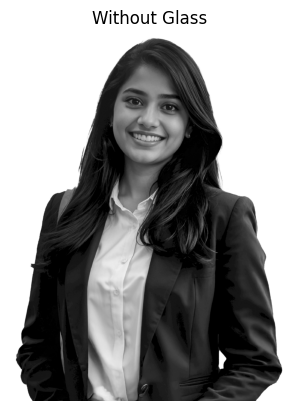

In [3]:
plt.imshow(wo_glass,cmap='gray')
plt.title("Without Glass")
plt.axis('off')
plt.show()

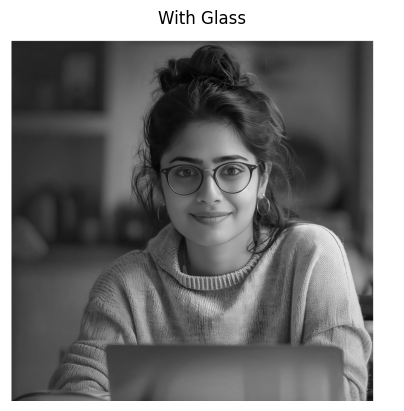

In [4]:
plt.imshow(w_glass,cmap='gray')
plt.title("With Glass")
plt.axis('off')
plt.show()

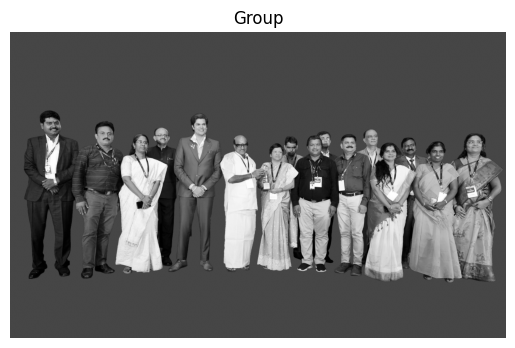

In [5]:
plt.imshow(group,cmap='gray')
plt.title("Group")
plt.axis('off')
plt.show()

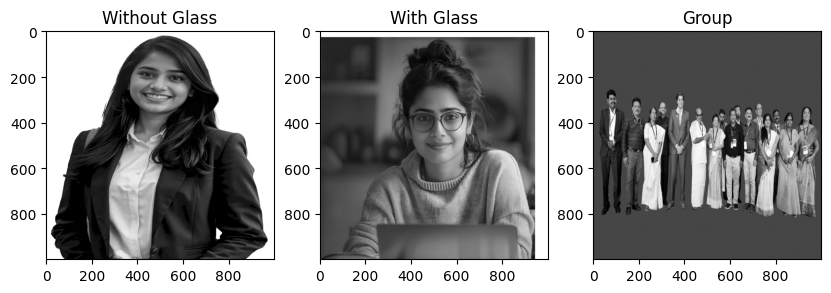

In [6]:
plt.figure(figsize=(10,10))
plt.subplot(131); plt.imshow(cv2.resize(wo_glass,(1000,1000)),cmap='gray'); plt.title("Without Glass")
plt.subplot(132); plt.imshow(cv2.resize(w_glass,(1000,1000)),cmap = 'gray'); plt.title("With Glass")
plt.subplot(133); plt.imshow(cv2.resize(group,(1000,1000)),cmap = 'gray'); plt.title("Group")
plt.show()

# Cascade Files

OpenCV comes with these pre-trained cascade files, we've relocated the .xml files for you in our own DATA folder

# Face Detection

In [7]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

In [8]:
def detectface(img):
    if len(img.shape)!=2:
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    face_img = img.copy()
    face_rects = face_cascade.detectMultiScale(face_img, scaleFactor = 1.2, minNeighbors = 5)
    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h),(255,255,255),10)
        plt.imshow(face_img,cmap='gray')
    return face_img

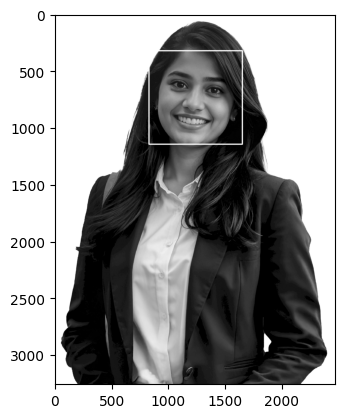

In [9]:
res = detectface(wo_glass)

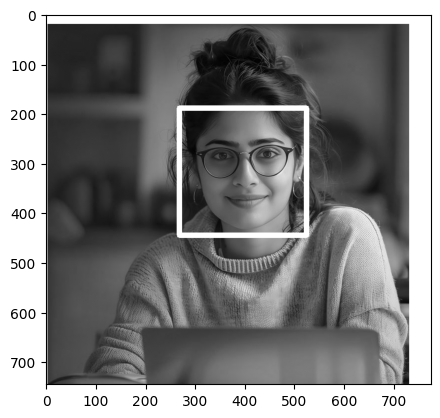

In [10]:
res1 = detectface(w_glass)

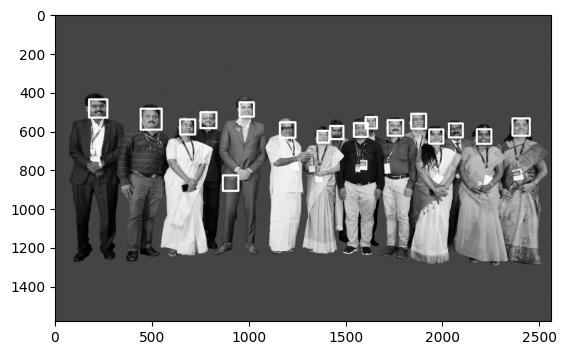

In [11]:
res2 = detectface(group)

In [12]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

In [13]:
def detecteye(img):
    face_img = img.copy()
    eye_rects = eye_cascade.detectMultiScale(face_img, scaleFactor = 1.3, minNeighbors = 5)
    for (x,y,w,h) in eye_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h),(255,255,255),10)
        plt.imshow(face_img,cmap='gray')
    return face_img
    

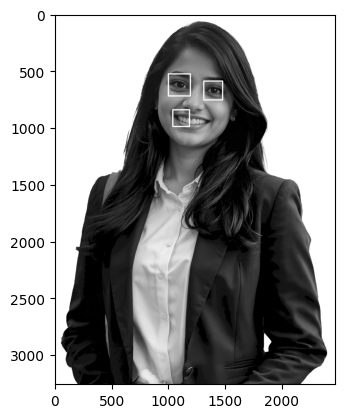

In [14]:
res = detecteye(wo_glass)

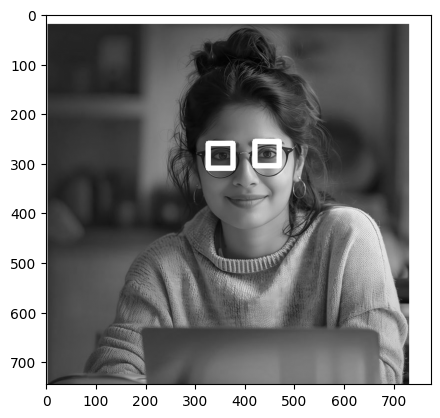

In [15]:
res1 = detecteye(w_glass)

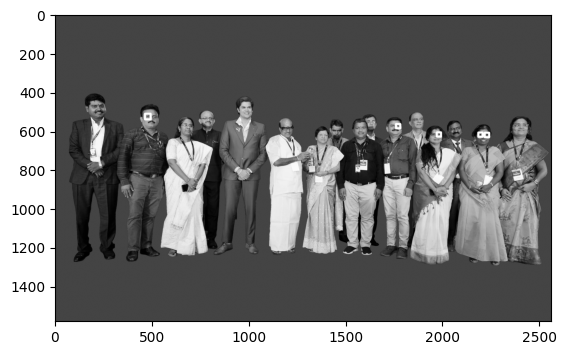

In [16]:
res2 = detecteye(group)

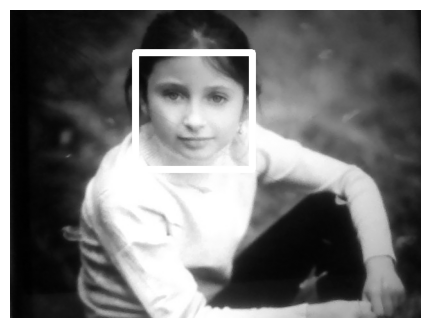

In [ ]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        continue
    result = detectface(frame)

    plt.figure(figsize=(6,4))
    plt.imshow(result, cmap='gray')
    plt.axis('off')
    display(plt.gcf())
    plt.close()
    clear_output(wait=True)